In [114]:
import yaml
import numpy as np
import os
import pandas as pd
import random
from pathlib import Path
from src.data_pipeline import segment_signal, perform_fft_on_segments
import matplotlib.pyplot as plt
from src.data_pipeline import create_metadata_df, load_measurement
import plotly.express as px
from scipy.signal import resample, find_peaks, spectrogram
from typing import Tuple, List
from tqdm.auto import tqdm
from sklearn.manifold import TSNE

In [115]:
SEED = 0xDEAD
np.random.seed(SEED)
random.seed(SEED)

In [116]:
def interpolate_canonical(
    spectra: np.ndarray,
    freqs: np.ndarray,
    f_cut: float,
    f_out: int,
) -> Tuple[np.ndarray, np.ndarray]:
    if spectra.ndim != 2:
        raise ValueError("`spectra` must be 2-D (N, F)")
    if freqs.ndim != 1:
        raise ValueError("`freqs` must be 1-D (F,)")
    if spectra.shape[1] != freqs.size:
        raise ValueError("Dimension mismatch between `spectra` and `freqs`")
    f_star = np.linspace(0.0, f_cut, f_out, endpoint=False, dtype=np.float32)
    out = np.empty((spectra.shape[0], f_out), dtype=np.float32)
    for i, row in enumerate(spectra):
        out[i] = np.interp(f_star, freqs, row).astype(np.float32)
    return out, f_star

In [117]:
state2name = {
    1: "rotor bar defect",
    2: "normal",
    3: "bearing defect",
    4: "inter-turn short circuits"
}
base_dir = "../dataset/engine_2"
path2metadata = os.path.join(base_dir, 'metadata.csv')
if os.path.isfile(path2metadata):
    metadata_df = pd.read_csv(os.path.join(path2metadata))
    metadata_df.set_index('measurement_id', inplace=True)
else:
    metadata_df = create_metadata_df(base_dir, state2name)
    metadata_df.to_csv(path2metadata)
real_df = metadata_df[(metadata_df.state == 'normal') & (metadata_df.load_condition == 100)]

In [118]:
real_df.head()

,base_id,experiment,state,load_condition,phase,num_observations,file_path,engine_cfg_path
measurement_id,,,,,,,,
1727791012_1,1727791012,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791211_1,1727791211,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790910_1,1727790910,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727790870_1,1727790870,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml
1727791170_1,1727791170,experiment_1,normal,100,1,16384,../dataset/engine_2/experiment_1/current/2nd_l...,../dataset/engine_2/engine.yml


In [119]:
simulated_files = list(map(str, Path('../Faulty_AC_motor_001').glob('nofault_*.csv')))
simulated_df = pd.DataFrame({'file_path': simulated_files})

def get_phase(x):
    phase = x.split('\\')[2].split('_')[-1].split('.')[0]
    return 1 if phase == 'phaseA' else 2 if phase == 'phaseB' else 3

def get_num_observations(x):
    return pd.read_csv(x).shape[0]

def get_measurement_id(x):
    return f'{x.state}_{x.phase}'

simulated_df['state'] = 'normal'
simulated_df['load_condition'] = 100
simulated_df['experiment'] = 'experiment_2'
simulated_df['phase'] = simulated_df.file_path.apply(get_phase)
simulated_df['num_observations'] = simulated_df.file_path.apply(get_num_observations)
simulated_df['measurement_id'] = simulated_df.apply(get_measurement_id, axis=1)
simulated_df = simulated_df.reset_index(drop=True).set_index('measurement_id')
simulated_df.head()

,file_path,state,load_condition,experiment,phase,num_observations
measurement_id,,,,,,
normal_1,..\Faulty_AC_motor_001\nofault_load100_phaseA.csv,normal,100,experiment_2,1,16666
normal_2,..\Faulty_AC_motor_001\nofault_load100_phaseB.csv,normal,100,experiment_2,2,16666
normal_3,..\Faulty_AC_motor_001\nofault_load100_phaseC.csv,normal,100,experiment_2,3,16666


In [120]:
real_measurement = '1727790910_1'
sim_measurement = 'normal_1'

real_norm_df = load_measurement(real_measurement, real_df)
sim_norm_df = load_measurement(sim_measurement, simulated_df)
sim_norm_df.index = sim_norm_df.index * 1000

In [121]:
fig = px.line(
    real_norm_df,
    x=real_norm_df.index,
    y='Current',
    title=f'Real Signal Over Time (no faults). ID: {real_measurement}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [122]:
fig = px.line(
    sim_norm_df,
    x=sim_norm_df.index,
    y='Current',
    title=f'Simulated Signal Over Time (no faults). ID: {sim_measurement}',
    labels={'x': 'Time, ms', 'Current': 'Current'},
    template='plotly_white'
)

fig.update_layout(
    xaxis_title="Time, ms",
    yaxis_title="Current"
)

fig.show()

In [123]:
with open("../training_configs/train_engine-2.yml", "r") as f:
    train_params = yaml.safe_load(f)

f_sampling = train_params["processing_parameters"]["f_sampling"]
shift = train_params["processing_parameters"]["shift"]
segment_length = train_params["processing_parameters"]["segment_length"]
cutoff_freq = train_params["processing_parameters"]["cutoff_freq"]
peak_type = train_params["processing_parameters"]["peak_type"]
peak_segment = train_params["processing_parameters"]["peak_segment"]
amplitude_range = tuple(train_params["processing_parameters"]["amplitude_range"])
sigma_range = tuple(train_params["processing_parameters"]["sigma_range"])
noise_factor = train_params["processing_parameters"]["noise_factor"]

num_epochs_binary = train_params["training_parameters"]["num_epochs_binary"]
num_epochs_multi = train_params["training_parameters"]["num_epochs_multi"]

batch_size = train_params["data_parameters"]["batch_size"]

normalization_method = train_params["dataset_parameters"]["normalization_method"]

train_params

{'engineLabel': 'engine_2',
 'task': 'binary',
 'model': 'ResNet',
 'test_run': False,
 'comet_online': False,
 'seed': 42,
 'processing_parameters': {'f_sampling': 4098,
  'shift': 20,
  'segment_length': 10000,
  'cutoff_freq': 250,
  'db': True,
  'peak_type': 'gaussian',
  'peak_segment': 4,
  'amplitude_range': [0.5, 20.0],
  'sigma_range': [0.5, 1.5],
  'noise_factor': 0.0,
  'include_negative_peaks': True,
  'random_peak_position': True,
  'fault_types_to_use': ['inter-turn short circuits', 'rotor bar defect'],
  'loads_to_use': [0, 20, 40, 60, 80, 100],
  'phases_to_use': [1, 2, 3]},
 'model_parameters': {'attention_module': False, 'dropout': 0.2},
 'training_parameters': {'num_epochs_binary': 30,
  'num_epochs_multi': 30,
  'initial_lr': 0.001,
  'patience': 10},
 'data_parameters': {'batch_size': 4096},
 'dataset_parameters': {'batch_size': 4096,
  'normalization_method': 'min-max',
  'normalization_mode': 'global',
  'real_fault_train': 0,
  'test_size': 0.3,
  'val_size': 0

In [124]:
real_segments = segment_signal(
    real_norm_df['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)

print(f'Shape: {real_segments.shape[0]} segments of size {real_segments.shape[1]}')

real_fft, real_freqs = perform_fft_on_segments(
    real_segments, 
    f_sampling, 
    db=True, 
    cutoff_freq=cutoff_freq
)

Shape: 320 segments of size 10000


In [125]:
sim_segments = segment_signal(
    sim_norm_df['Current'].dropna().values, 
    segment_length=segment_length, 
    step=shift, 
    apply_window=False
)
print(f'Shape: {sim_segments.shape[0]} segments of size {sim_segments.shape[1]}')

f_sampling_sim = 12800
sim_fft, sim_freqs = perform_fft_on_segments(
    sim_segments, 
    f_sampling_sim, 
    db=True, 
    cutoff_freq=cutoff_freq
)

Shape: 334 segments of size 10000


In [126]:
resampled_fft, resampled_freqs = interpolate_canonical(sim_fft, sim_freqs, cutoff_freq, len(real_freqs))

In [127]:
np.abs(real_freqs - resampled_freqs).max()

np.float64(0.38716442871097456)

In [128]:
def tight_plots(ax):
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

def plot_single_segment_with_uncertainty(fft_segments, 
                                         x_values=None, 
                                         max_points=1000, 
                                         n_std=2, 
                                         title="Spectrum with Uncertainty",
                                         axis_labels=None, 
                                         highlight_freqs=None, 
                                         method='closest',
                                         inplace=True):
    spectrum_mean = np.mean(fft_segments, axis=0)
    spectrum_std = np.std(fft_segments, axis=0) * n_std 

    if max_points is not None and len(spectrum_mean) > max_points:
        spectrum_mean = resample(spectrum_mean, max_points)
        spectrum_std = resample(spectrum_std, max_points)
        if x_values is not None:
            if len(x_values.shape) == 1:
                x_values = resample(x_values, max_points)
            else:
                x_values = resample(x_values, max_points)
        else:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))
    else:
        if x_values is None:
            x_values = np.linspace(0, len(spectrum_mean), len(spectrum_mean))

    x_label, y_label = axis_labels if axis_labels else ('Frequency, Hz', 'Power, dB')
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(x_values, spectrum_mean, linewidth=2.0, color='blue', label='Mean Spectrum')
    ax.fill_between(
        x_values,
        spectrum_mean - spectrum_std,
        spectrum_mean + spectrum_std,
        color='blue',
        alpha=0.2,
        label=f'Uncertainty (±{n_std} SD)'
    )

    ax.plot(x_values, spectrum_mean - spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    ax.plot(x_values, spectrum_mean + spectrum_std, linewidth=1.0, color='darkblue', linestyle='--')
    
    if highlight_freqs is not None and len(highlight_freqs) > 0:
        for freq in highlight_freqs:
            if method == 'closest':
                closest_idx = np.abs(x_values - freq).argmin()
                ax.scatter(x_values[closest_idx], spectrum_mean[closest_idx], color='red', s=50)
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel(x_label, fontsize=9)
    ax.set_ylabel(y_label, fontsize=9)
    ax.grid(True, linestyle='--', linewidth=0.5)

    if inplace:
        tight_plots(ax)

    return fig, ax

In [129]:
max_points = 1000
mean_real_spectrum = np.mean(real_fft, axis=0)
if len(mean_real_spectrum) > max_points:
    mean_real_spectrum = resample(mean_real_spectrum, max_points)
peaks, _ = find_peaks(mean_real_spectrum, height=20)
#peaks = np.insert(peaks, 0, 0)
#peaks

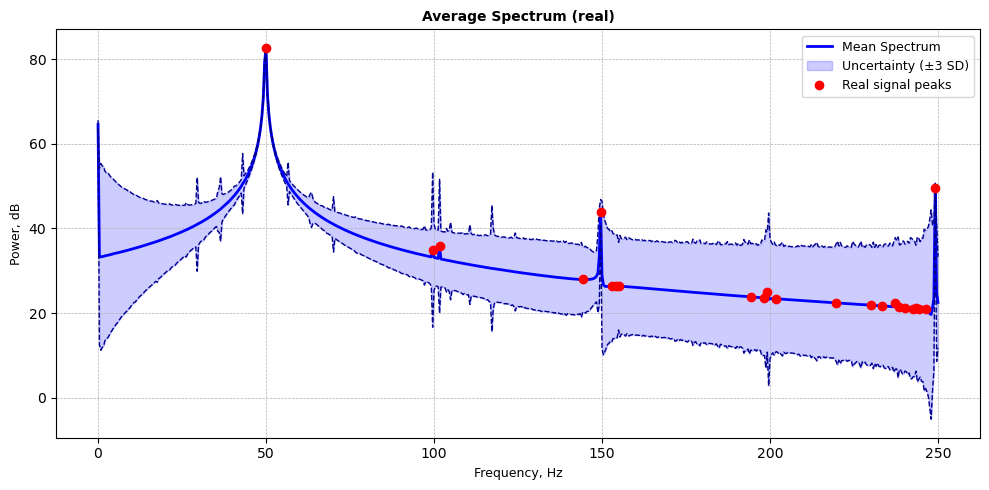

In [130]:
fig, ax = plot_single_segment_with_uncertainty(real_fft, 
                                               x_values=real_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (real)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

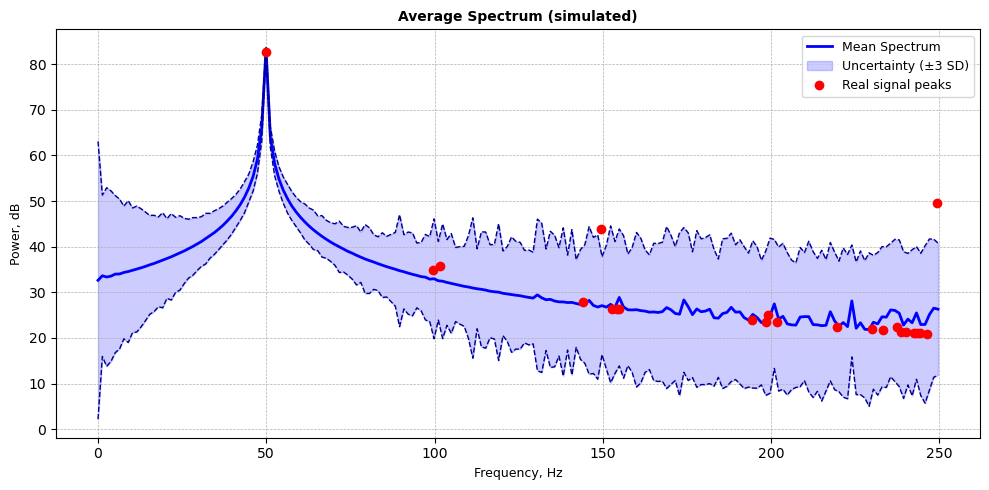

In [131]:
fig, ax = plot_single_segment_with_uncertainty(sim_fft, 
                                               x_values=sim_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (simulated)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

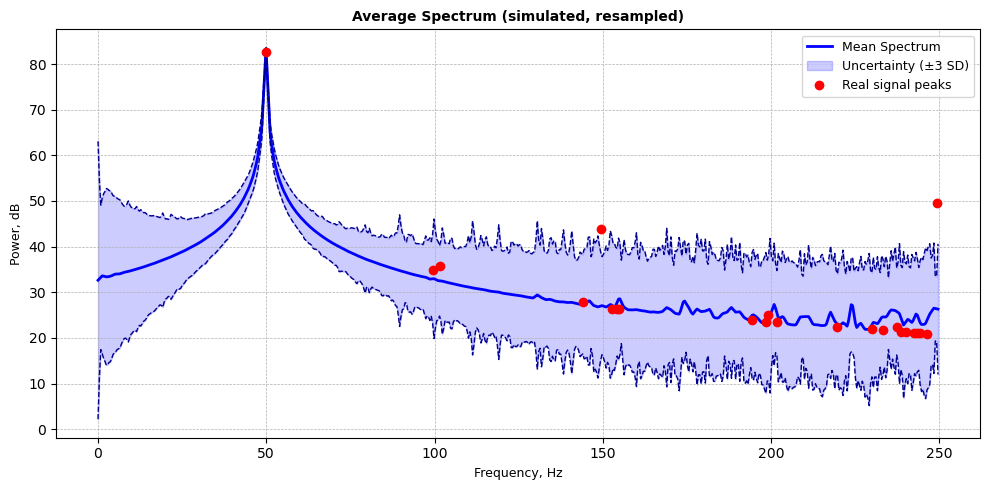

In [132]:
fig, ax = plot_single_segment_with_uncertainty(resampled_fft, 
                                               x_values=resampled_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (simulated, resampled)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

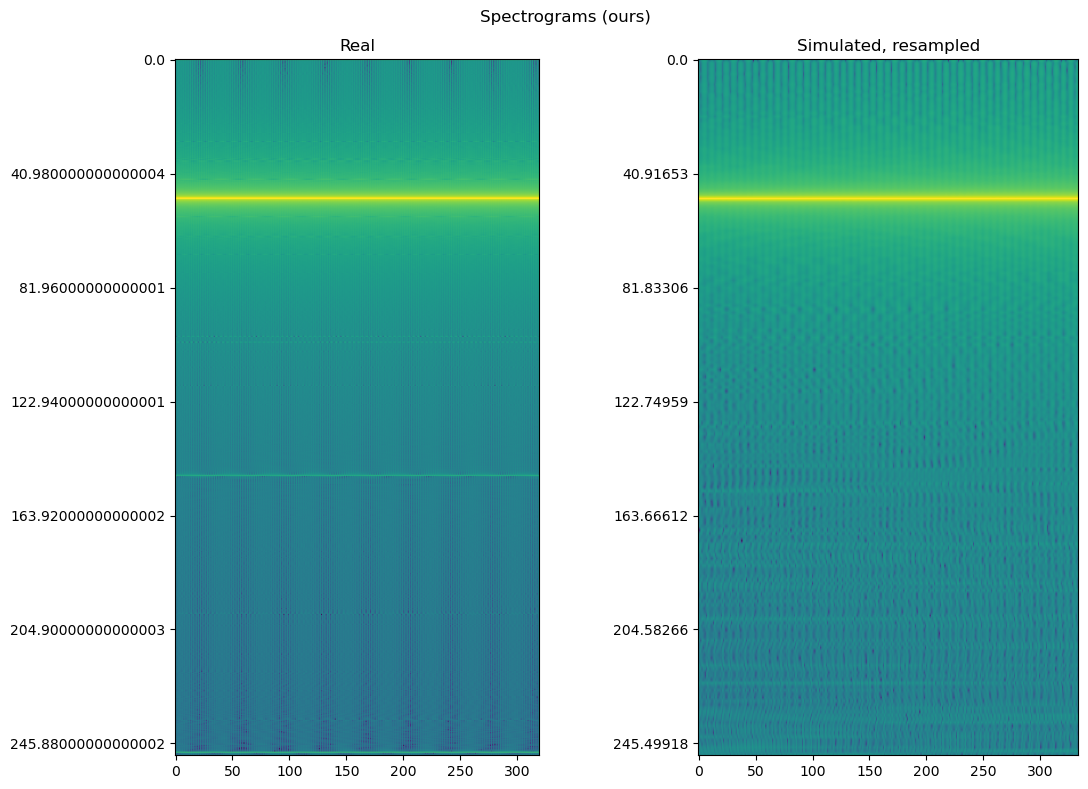

In [133]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 8))
yticks = [i * 100 for i in range(real_fft.T.shape[0] // 100 + 1)]
ax[0].imshow(real_fft.T)
ax[0].set_title('Real')
ax[0].set_yticks(yticks, real_freqs[yticks])
ax[1].imshow(resampled_fft.T)
ax[1].set_title('Simulated, resampled')
ax[1].set_yticks(yticks, resampled_freqs[yticks])
fig.suptitle('Spectrograms (ours)')
plt.tight_layout()
plt.show()

In [134]:
def preprocessing(
    metadata_df: pd.DataFrame,
    out_dir: str,
    segment_length: int,
    step: int,
    f_sampling: int,
    cutoff_freq: int,
    apply_window: bool = False,
    db: bool = True,
) -> Tuple[np.ndarray, pd.DataFrame, np.ndarray]:
    seg_meta_rows: List[dict] = []
    seg_arrays: List[np.ndarray] = []

    for m_id, meta in tqdm(metadata_df.iterrows(),
                           total=len(metadata_df),
                           desc="pre-processing"):
        df = load_measurement(m_id, metadata_df)
        current = df["Current"].dropna().values
        windows = segment_signal(
            current,
            segment_length=segment_length,
            step=step,
            apply_window=apply_window,
        )
        fft_windows, freqs = perform_fft_on_segments(
            windows,
            f_sampling=f_sampling,
            cutoff_freq=cutoff_freq,
            db=db,
        )
        n_segments = fft_windows.shape[0]
        for s_idx in range(n_segments):
            start_t = df.index[s_idx * step]
            end_t   = df.index[s_idx * step + segment_length - 1]
            seg_meta_rows.append({
                "measurement_id": m_id,
                "segment_idx":    s_idx,
                "start_time":     float(start_t),
                "end_time":       float(end_t),
                "state":          meta["state"],
                "binary_label":   0 if meta["state"] == "normal" else 1,
                "multiclass_label": meta["state"],
                "phase":          int(meta["phase"]),
                "load_condition": meta["load_condition"],
                "experiment":     meta["experiment"],
            })
        seg_arrays.append(fft_windows.astype(np.float32))
    segments = np.vstack(seg_arrays) 
    seg_meta_df = (
        pd.DataFrame(seg_meta_rows)
          .set_index(["measurement_id", "segment_idx"])
    )
    os.makedirs(out_dir, exist_ok=True)
    np.save(os.path.join(out_dir, "segments.npy"), segments)
    np.save(os.path.join(out_dir, "freqs.npy"), freqs)
    seg_meta_df.to_csv(os.path.join(out_dir, "segments_metadata.csv"))
    return segments, seg_meta_df, freqs

In [135]:
real_seg, real_seg_meta, real_freqs = preprocessing(real_df[real_df.phase == 1],
                                                    'real_data',
                                                    segment_length=segment_length,
                                                    step=shift,
                                                    f_sampling=f_sampling,
                                                    cutoff_freq=cutoff_freq
                                                    )

sim_seg, sim_seg_meta, sim_freqs = preprocessing(simulated_df,
                                                 'sim_data',
                                                 segment_length=segment_length,
                                                 step=shift,
                                                 f_sampling=f_sampling_sim,
                                                 cutoff_freq=cutoff_freq
                                                 )

pre-processing:   0%|          | 0/21 [00:00<?, ?it/s]

pre-processing:   0%|          | 0/3 [00:00<?, ?it/s]

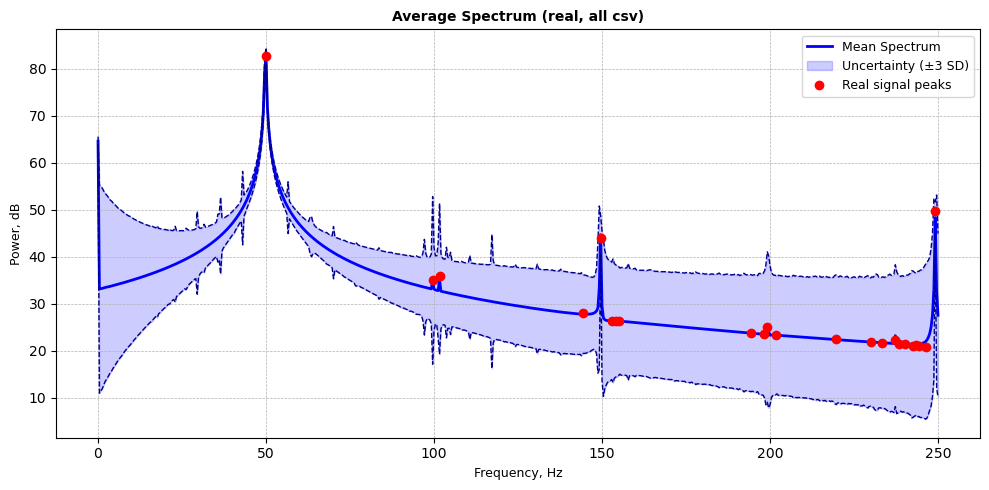

In [136]:
fig, ax = plot_single_segment_with_uncertainty(real_seg, 
                                               x_values=real_freqs, 
                                               n_std=3, 
                                               title='Average Spectrum (real, all csv)',
                                               inplace=False)
ax.plot(real_freqs[peaks], mean_real_spectrum[peaks], 'ro', label='Real signal peaks')
tight_plots(ax)

In [137]:
real_seg.shape, resampled_fft.shape

((6720, 611), (334, 611))

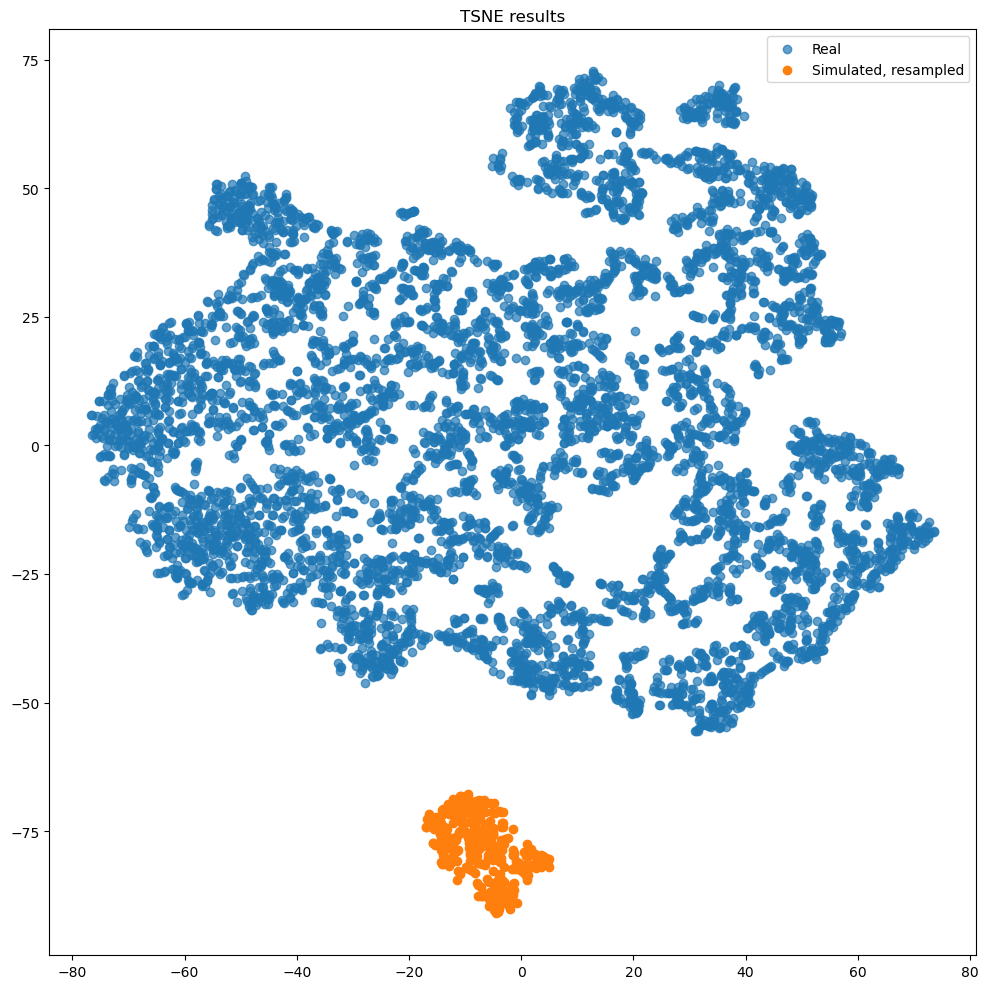

In [138]:
tsne = TSNE(n_components=2)
labels = np.array([0] * real_seg.shape[0] + [1] * resampled_fft.shape[0])
dots = tsne.fit_transform(np.vstack((real_seg, resampled_fft))[:, peaks])
real_dots = dots[labels == 0]
resampled_dots = dots[labels == 1]
plt.figure(figsize=(10, 10))
plt.scatter(real_dots[:, 0], real_dots[:, 1], alpha=0.7, label="Real")
plt.scatter(resampled_dots[:, 0], resampled_dots[:, 1], label="Simulated, resampled")
plt.legend()
plt.title('TSNE results')
plt.tight_layout()
plt.show()

In [139]:
def weighted_average_metric(metrics: np.ndarray, weights: np.ndarray) -> float:
    metrics = np.array(metrics)
    weights = np.array(weights)

    if len(metrics) == 0 or len(weights) == 0 or np.sum(weights) == 0:
        return 0.0

    return float(np.sum(metrics * weights) / np.sum(weights))


def spectral_entropy(fft_magnitude: np.ndarray, eps: float = 1e-12) -> float:
    fft_magnitude = np.array(fft_magnitude)
    power_spectrum = fft_magnitude ** 2
    power_sum = np.sum(power_spectrum) + eps
    p = power_spectrum / power_sum
    spectral_ent = -np.sum(p * np.log(p + eps))
    return float(spectral_ent)


def dominant_frequency_metric(
    fft_magnitude: np.ndarray,
    freqs: np.ndarray,
    target_freq: float = 50.0,
    freq_tolerance: float = 1.0
) -> float:
    fft_magnitude = np.array(fft_magnitude)
    freqs = np.array(freqs)

    mask_target = (freqs >= (target_freq - freq_tolerance)) & (freqs <= (target_freq + freq_tolerance))
    if not np.any(mask_target):
        return 0.0
    target_amp = float(np.mean(fft_magnitude[mask_target]))
    mask_rest = ~mask_target
    if np.any(mask_rest):
        rest_amp = float(np.mean(fft_magnitude[mask_rest]))
    else:
        rest_amp = 1e-8 
    ratio = (target_amp + 1e-12) / (rest_amp + 1e-12)
    return float(ratio)

In [140]:
mean_all_real_spectrum = np.mean(real_seg, axis=0)
for freq in [50, 100, 150, 200, 250]:
   dfm = dominant_frequency_metric(mean_all_real_spectrum, real_freqs, target_freq=freq)
   print(f'On {freq} Hz: DFM = {dfm}')
print(f'Spectral entropy = {spectral_entropy(mean_all_real_spectrum)}')

On 50 Hz: DFM = 2.328240931549931
On 100 Hz: DFM = 1.035487531590036
On 150 Hz: DFM = 0.9988110360918834
On 200 Hz: DFM = 0.735845790686273
On 250 Hz: DFM = 1.120350346302221
Spectral entropy = 6.226376533508301


In [141]:
mean_resampled_spectrum = np.mean(resampled_fft, axis=0)
for freq in [50, 100, 150, 200, 250]:
   dfm = dominant_frequency_metric(mean_resampled_spectrum, resampled_freqs, target_freq=freq)
   print(f'On {freq} Hz: DFM = {dfm}')
print(f'Spectral entropy = {spectral_entropy(mean_resampled_spectrum)}')

On 50 Hz: DFM = 2.3772739931250557
On 100 Hz: DFM = 1.012032341807296
On 150 Hz: DFM = 0.8279842385591991
On 200 Hz: DFM = 0.7912847284828429
On 250 Hz: DFM = 0.810496468883046
Spectral entropy = 6.241677284240723
